Using XRF data from rock core to predict lithofacies

Using Kmeans as starting place in unsupervised classification

In [26]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [27]:
# Load the data
df = pd.read_csv('xrf_data_core_g.csv')
df

,Depth (ft),Core,Mg,Al,Si,P,S,K,Ca,Ti,...,Cd,Sn,Sb,W,Hg,Pb,Bi,Th,U,LE
0,6834,1,2.13,9.06,27.78,0.1078,1.7445,3.4502,1.83,0.4833,...,ND,0,ND,ND,0,0,ND,0,ND,48.64
1,6835,1,1.99,6.14,34.72,ND,0.9209,2.1402,0.85,0.4005,...,ND,ND,ND,ND,ND,0,ND,0,ND,49.99
2,6835,1,1.90,6.03,35.24,0.0878,1.0137,2.1141,0.82,0.3679,...,ND,ND,ND,ND,ND,0,ND,ND,ND,49.78
3,6836,1,2.07,5.97,35.92,ND,1.1256,2.0897,0.57,0.3993,...,ND,ND,ND,ND,ND,0,ND,ND,ND,49.28
4,6836,1,1.79,5.50,35.77,ND,1.0598,1.8156,0.88,0.3497,...,ND,ND,ND,ND,0,0,ND,0,ND,50.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,8811,17,1.28,5.96,24.84,0.0943,2.1412,1.7811,9.52,0.2820,...,ND,ND,ND,ND,0.0005,0.0014,ND,0.0018,ND,50.95
2882,8811,17,1.39,6.04,23.02,0.0332,1.3074,1.5244,12.83,0.2818,...,ND,ND,ND,ND,ND,0.0010,ND,0.0021,ND,50.69
2883,8812,17,1.66,6.36,32.91,ND,1.8474,1.8111,0.67,0.3381,...,ND,ND,ND,0.0014,ND,0.0019,ND,0.0010,ND,50.88
2884,8812,17,1.73,5.73,21.82,0.0729,2.2459,1.4843,13.07,0.2790,...,ND,ND,ND,ND,0.0007,0.0015,ND,0.0015,ND,50.46


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2886 entries, 0 to 2885
Data columns (total 37 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Depth (ft)  2886 non-null   int64  
 1   Core        2886 non-null   int64  
 2   Mg          2886 non-null   object 
 3   Al          2886 non-null   object 
 4   Si          2886 non-null   float64
 5   P           2886 non-null   object 
 6   S           2886 non-null   object 
 7   K           2886 non-null   object 
 8   Ca          2886 non-null   object 
 9   Ti          2886 non-null   float64
 10  V           2886 non-null   object 
 11  Cr          2886 non-null   object 
 12  Mn          2886 non-null   object 
 13  Fe          2886 non-null   float64
 14  Co          2886 non-null   object 
 15  Ni          2886 non-null   object 
 16  Cu          2886 non-null   object 
 17  Zn          2886 non-null   object 
 18  As          2886 non-null   object 
 19  Se          2886 non-null  

In [29]:
# Replace ND (not detected) with 0
df_cleaned = df.replace('ND', 0)

In [30]:
# Change data type to numeric for modeling
df_cleaned = df_cleaned.astype(float)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2886 entries, 0 to 2885
Data columns (total 37 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Depth (ft)  2886 non-null   float64
 1   Core        2886 non-null   float64
 2   Mg          2886 non-null   float64
 3   Al          2886 non-null   float64
 4   Si          2886 non-null   float64
 5   P           2886 non-null   float64
 6   S           2886 non-null   float64
 7   K           2886 non-null   float64
 8   Ca          2886 non-null   float64
 9   Ti          2886 non-null   float64
 10  V           2886 non-null   float64
 11  Cr          2886 non-null   float64
 12  Mn          2886 non-null   float64
 13  Fe          2886 non-null   float64
 14  Co          2886 non-null   float64
 15  Ni          2886 non-null   float64
 16  Cu          2886 non-null   float64
 17  Zn          2886 non-null   float64
 18  As          2886 non-null   float64
 19  Se          2886 non-null  

In [31]:
#scale the data for model fitting
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

In [15]:
scaled_data

array([[-1.81526761, -2.0171754 ,  0.46238235, ..., -0.84756873,
        -0.2775089 , -1.59702507],
       [-1.81353534, -2.0171754 ,  0.24995786, ..., -0.84756873,
        -0.2775089 , -0.75809371],
       [-1.81353534, -2.0171754 ,  0.11339926, ..., -0.84756873,
        -0.2775089 , -0.88859414],
       ...,
       [ 1.61114868,  0.97102168, -0.250757  , ...,  0.29996521,
        -0.2775089 , -0.20502043],
       [ 1.61114868,  0.97102168, -0.14454476, ...,  0.87373219,
        -0.2775089 , -0.4660213 ],
       [ 1.61288094,  0.97102168, -0.55422056, ...,  0.87373219,
        -0.2775089 ,  0.4101959 ]])

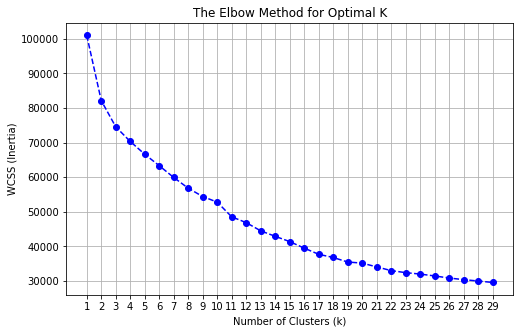

In [25]:
#visualize the data to estimate the best number of categories
# Calculate WCSS (Inertia) for different numbers of clusters
wcss = []
cluster_range = range(1, 30)  # Checking 1 to 30 clusters

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)  # Inertia is the WCSS

# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()


In [32]:
# Define the model, use the number of classifications or clusters that the model predicted and predict the lithofacies class
kmeans = KMeans(n_clusters = 11, random_state = 42, n_init = 10)
df_cleaned['lithofacies'] = kmeans.fit_predict(scaled_data)

In [34]:
# Inspect
df_cleaned

,Depth (ft),Core,Mg,Al,Si,P,S,K,Ca,Ti,...,Sn,Sb,W,Hg,Pb,Bi,Th,U,LE,lithofacies
0,6834.0,1.0,2.13,9.06,27.78,0.1078,1.7445,3.4502,1.83,0.4833,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0,48.64,2
1,6835.0,1.0,1.99,6.14,34.72,0.0000,0.9209,2.1402,0.85,0.4005,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0,49.99,2
2,6835.0,1.0,1.90,6.03,35.24,0.0878,1.0137,2.1141,0.82,0.3679,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0,49.78,2
3,6836.0,1.0,2.07,5.97,35.92,0.0000,1.1256,2.0897,0.57,0.3993,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0,49.28,2
4,6836.0,1.0,1.79,5.50,35.77,0.0000,1.0598,1.8156,0.88,0.3497,...,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0000,0.0,50.55,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2881,8811.0,17.0,1.28,5.96,24.84,0.0943,2.1412,1.7811,9.52,0.2820,...,0.0,0.0,0.0000,0.0005,0.0014,0.0,0.0018,0.0,50.95,0
2882,8811.0,17.0,1.39,6.04,23.02,0.0332,1.3074,1.5244,12.83,0.2818,...,0.0,0.0,0.0000,0.0000,0.0010,0.0,0.0021,0.0,50.69,0
2883,8812.0,17.0,1.66,6.36,32.91,0.0000,1.8474,1.8111,0.67,0.3381,...,0.0,0.0,0.0014,0.0000,0.0019,0.0,0.0010,0.0,50.88,0
2884,8812.0,17.0,1.73,5.73,21.82,0.0729,2.2459,1.4843,13.07,0.2790,...,0.0,0.0,0.0000,0.0007,0.0015,0.0,0.0015,0.0,50.46,0


In [37]:
df_cleaned.describe()

,Depth (ft),Core,Mg,Al,Si,P,S,K,Ca,Ti,...,Sn,Sb,W,Hg,Pb,Bi,Th,U,LE,lithofacies
count,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,...,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000,2886.000000
mean,7881.916840,11.800762,1.825263,5.126292,27.834941,0.076846,1.213732,1.550371,7.991677,0.314158,...,0.000029,0.000001,0.000216,0.000112,0.001039,0.000001,0.000739,0.000110,51.209917,2.681566
std,577.379574,5.355327,0.659172,2.024966,8.220151,0.354629,0.671752,0.778211,10.919103,0.123597,...,0.000288,0.000065,0.000513,0.000228,0.000661,0.000033,0.000872,0.000395,1.609469,3.027451
min,6834.000000,1.000000,0.000000,0.000000,1.550000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.390000,0.000000
25%,7470.250000,6.000000,1.490000,4.050000,25.430000,0.000000,0.732375,1.014025,1.210000,0.265150,...,0.000000,0.000000,0.000000,0.000000,0.000600,0.000000,0.000000,0.000000,50.250000,0.000000
50%,7975.500000,15.000000,1.710000,5.580000,30.945000,0.000000,1.177250,1.724300,2.525000,0.341400,...,0.000000,0.000000,0.000000,0.000000,0.001200,0.000000,0.000900,0.000000,51.050000,1.000000
75%,8353.000000,16.000000,1.960000,6.550000,33.110000,0.028225,1.586300,2.123525,10.130000,0.385175,...,0.000000,0.000000,0.000000,0.000000,0.001500,0.000000,0.001300,0.000000,51.947500,5.000000
max,8813.000000,17.000000,7.710000,9.720000,44.820000,8.882100,6.302900,3.717800,44.030000,3.627100,...,0.003400,0.003500,0.005500,0.001200,0.004100,0.001000,0.012300,0.006300,65.820000,10.000000
